In [33]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [34]:
# параметры
dt = 0.05
input_steps = 4000
pred_steps = int(50 / dt)

# Загрузка данных
train = pd.read_csv('train.csv', header=None).to_numpy()
etalon_train = pd.read_csv('etalon_for_train.csv', header=None).to_numpy()
test = pd.read_csv('test.csv', header=None).to_numpy()
etalon_test = pd.read_csv('etalon_for_test.csv', header=None).to_numpy()

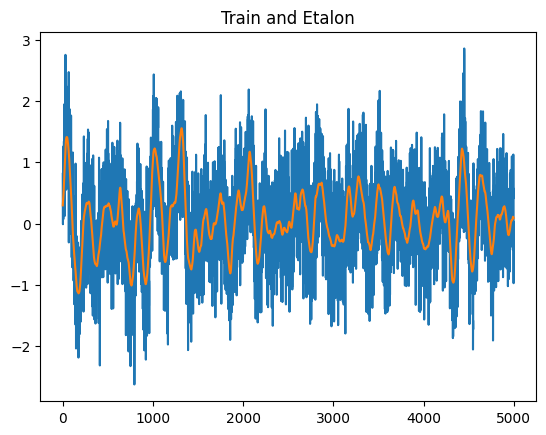

In [35]:
plt.figure()
plt.plot(train[0])
plt.plot(etalon_train[0])
plt.title("Train and Etalon")
plt.show()

In [36]:
X_train = train[:, :input_steps]      # признаки: предыдущие 4000 отсчетов
y_train = train[:, input_steps:input_steps+pred_steps]  # прогноз: следующие 1000 отсчетов

# Нормализация
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

In [ ]:
# Обучение Ridge-регрессии
ridge = Ridge(alpha=1000)
ridge.fit(X_train_scaled, y_train_scaled)

# Прогноз для тестовой выборки
X_test = test[:, :input_steps]
X_test_scaled = scaler_X.transform(X_test)
y_pred_scaled = ridge.predict(X_test_scaled)

# Обратная нормализация
predictions = scaler_y.inverse_transform(y_pred_scaled)
etalon_slice = etalon_test[:, :pred_steps]

# Средняя ошибка
mean_error = np.mean(predictions - etalon_slice, axis=0)

# RMSE
rmse = np.sqrt(np.mean((predictions - etalon_slice)**2, axis=0))

# Ошибка по всем реализациям
ME_total = np.mean(predictions - etalon_slice)
RMSE_total = np.sqrt(np.mean((predictions - etalon_slice)**2))

print(f"Средняя ошибка (ME): {ME_total:.6f}")
print(f"Среднеквадратичная ошибка (RMSE): {RMSE_total:.6f}")

Средняя ошибка (ME): -0.001360
Среднеквадратичная ошибка (RMSE): 0.625350


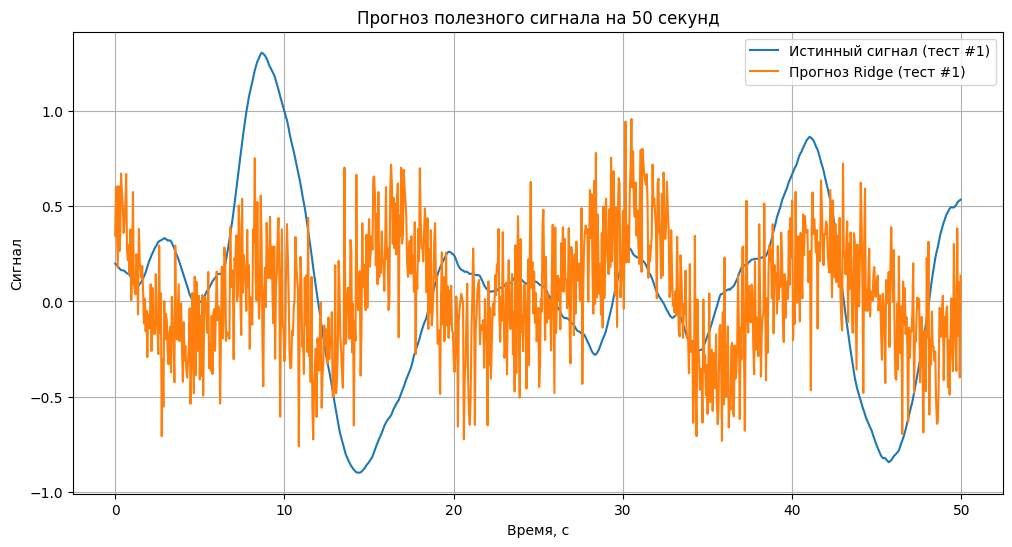

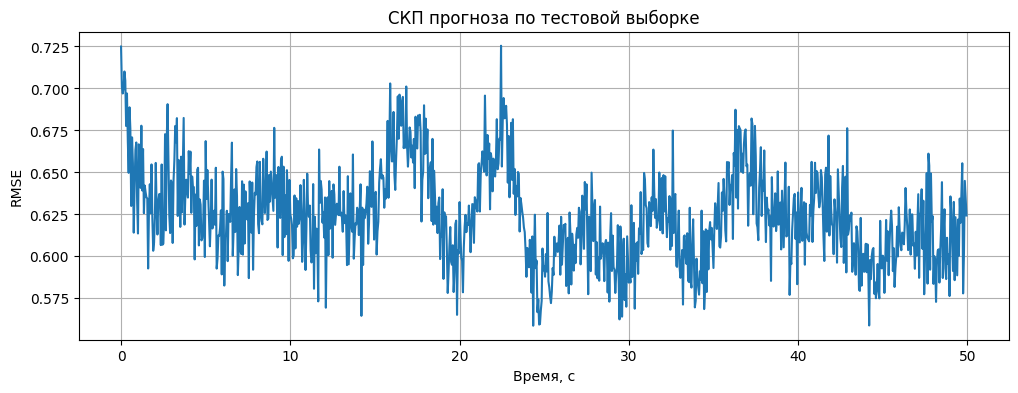

In [41]:
# Визуализация первой тестовой реализации
plt.figure(figsize=(12,6))
plt.plot(np.arange(pred_steps)*dt, etalon_slice[5], label='Истинный сигнал (тест #1)')
plt.plot(np.arange(pred_steps)*dt, predictions[5], label='Прогноз Ridge (тест #1)')
plt.xlabel('Время, с')
plt.ylabel('Сигнал')
plt.title('Прогноз полезного сигнала на 50 секунд')
plt.legend()
plt.grid(True)
plt.show()

# Визуализация RMSE по времени
plt.figure(figsize=(12,4))
plt.plot(np.arange(pred_steps)*dt, rmse, label='RMSE по времени')
plt.xlabel('Время, с')
plt.ylabel('RMSE')
plt.title('СКП прогноза по тестовой выборке')
plt.grid(True)
plt.show()